## Problema de Mezcla de Gasolina

Los productos de gasolina incluyen gasolina regular y premium. Además del precio actual, las especificaciones incluyen

Octano: el octanaje mínimo para uso en carretera. El octanaje para uso en carretera se calcula como el promedio del índice de octano de investigación (RON) y el índice de octano de motor (MON).

Presión de vapor Reid. Se especifican los límites superior e inferior para la presión de vapor Reid. La presión de vapor Reid es la presión absoluta ejercida por el líquido a 38 °C (100 °F).

Benceno: el porcentaje máximo de volumen de benceno permitido en el producto final. El benceno ayuda a aumentar el octanaje, pero también es un contaminante ambiental peligroso.

In [1]:
import pandas as pd
products = {
    'Regular' : {'price': 2.75, 'octane': 87, 'RVPmin': 0.0, 'RVPmax': 15.0, 'benzene': 1.1},
    'Premium' : {'price': 2.85, 'octane': 91, 'RVPmin': 0.0, 'RVPmax': 15.0, 'benzene': 1.1},
}
df=pd.DataFrame.from_dict(products).T
df

/Users/erickavendanogarcia/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,price,octane,RVPmin,RVPmax,benzene
Regular,2.75,87.0,0.0,15.0,1.1
Premium,2.85,91.0,0.0,15.0,1.1


In [2]:
streams = {
    'Butane'       : {'RON': 93.0, 'MON': 92.0, 'RVP': 54.0, 'benzene': 0.00, 'cost': 0.85, 'avail': 30000},
    'LSR'          : {'RON': 78.0, 'MON': 76.0, 'RVP': 11.2, 'benzene': 0.73, 'cost': 2.05, 'avail': 35000},
    'Isomerate'    : {'RON': 83.0, 'MON': 81.1, 'RVP': 13.5, 'benzene': 0.00, 'cost': 2.20, 'avail': 0},
    'Reformate'    : {'RON':100.0, 'MON': 88.2, 'RVP':  3.2, 'benzene': 1.85, 'cost': 2.80, 'avail': 60000},
    'Reformate LB' : {'RON': 93.7, 'MON': 84.0, 'RVP':  2.8, 'benzene': 0.12, 'cost': 2.75, 'avail': 0},
    'FCC Naphtha'  : {'RON': 92.1, 'MON': 77.1, 'RVP':  1.4, 'benzene': 1.06, 'cost': 2.60, 'avail': 70000},
    'Alkylate'     : {'RON': 97.3, 'MON': 95.9, 'RVP':  4.6, 'benzene': 0.00, 'cost': 2.75, 'avail': 40000},
}

# calculate road octane as (R+M)/2
for s in streams.keys():
    streams[s]['octane'] = (streams[s]['RON'] + streams[s]['MON'])/2

# display feed information
df1=pd.DataFrame.from_dict(streams).T
df1

,RON,MON,RVP,benzene,cost,avail,octane
Butane,93.0,92.0,54.0,0.00,0.85,30000.0,92.50
LSR,78.0,76.0,11.2,0.73,2.05,35000.0,77.00
Isomerate,83.0,81.1,13.5,0.00,2.20,0.0,82.05
Reformate,100.0,88.2,3.2,1.85,2.80,60000.0,94.10
Reformate LB,93.7,84.0,2.8,0.12,2.75,0.0,88.85
FCC Naphtha,92.1,77.1,1.4,1.06,2.60,70000.0,84.60
Alkylate,97.3,95.9,4.6,0.00,2.75,40000.0,96.60


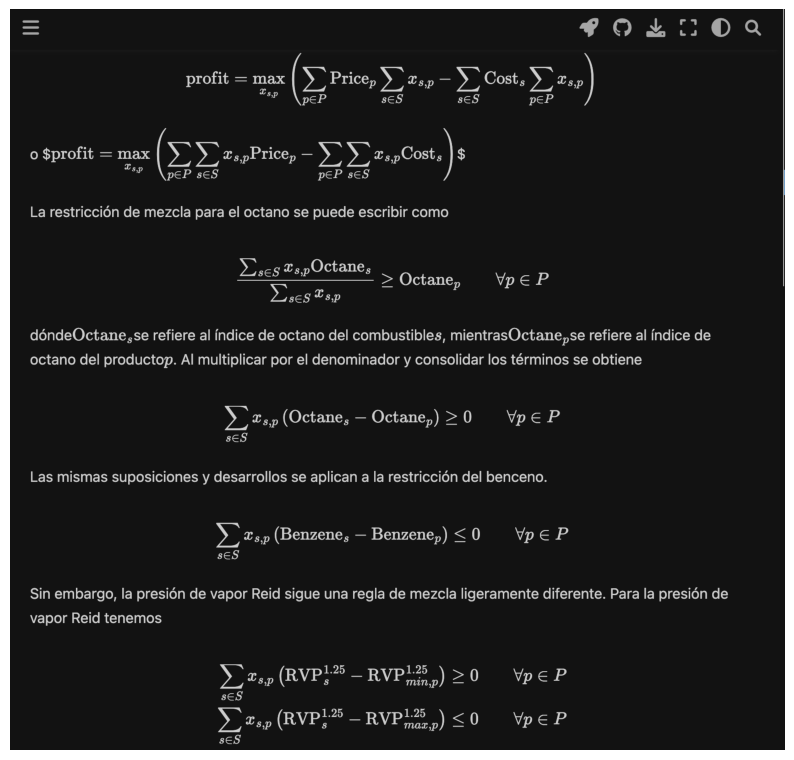

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Cargar la imagen
img = mpimg.imread('/Users/erickavendanogarcia/Desktop/A.png')

# 2. Ajustar el tamaño de la figura (en pulgadas)
plt.figure(figsize=(10, 10))

plt.imshow(img)
plt.axis('off')
plt.show()

### Cargamos las librerías

In [4]:
## Cargamos las librerías
import pyomo.environ as pe
import pyomo.opt as po

### Implementación del modelo
Nota importante $p \in Product$, $s \in Streams$

In [5]:
model=pe.ConcreteModel()

In [6]:
# Conjunto de productos, declaramos los productos del DataFrame
model.PRODUCTS = pe.Set(initialize=df.index.tolist())
model.STREAMS= pe.Set(initialize=df1.index.tolist())

#Parámetros
model.price = pe.Param(model.PRODUCTS, initialize=df['price'].to_dict())
model.cost=pe.Param(model.STREAMS, initialize=df1['cost'].to_dict())
model.octano_p=pe.Param(model.PRODUCTS, initialize=df['octane'].to_dict())
model.octano_s=pe.Param(model.STREAMS, initialize=df1['octane'].to_dict())
model.benzeno_p = pe.Param(model.PRODUCTS, initialize=df['benzene'].to_dict())
model.benzeno_s = pe.Param(model.STREAMS, initialize=df1['benzene'].to_dict())
model.avail = pe.Param(model.STREAMS, initialize=df1['avail'].to_dict())

In [7]:
model.RVP_s= pe.Param(model.STREAMS, initialize=df1['RVP'].to_dict())
model.RVP_min=pe.Param(model.PRODUCTS, initialize=df['RVPmin'].to_dict())
model.RVP_max=pe.Param(model.PRODUCTS, initialize=df['RVPmax'].to_dict())

In [8]:
# Aquí definimos la x

model.x= pe.Var(model.STREAMS,model.PRODUCTS, domain=pe.PositiveReals)

### Definimos las contricciones

In [9]:
#Definimos nuestras constricciones
def cons(model, p):
    return sum(
        (model.benzeno_s[s] - model.benzeno_p[p]) * model.x[s, p]
        for s in model.STREAMS
    ) <= 0

model.constricion = pe.Constraint(model.PRODUCTS, rule=cons)

In [10]:
def cons1(model, p):
    return sum(
        (model.octano_s[s] - model.octano_p[p]) * model.x[s, p]
        for s in model.STREAMS
    ) >= 0

model.constricion1 = pe.Constraint(model.PRODUCTS, rule=cons1)

In [11]:
def cons2(model, p):
    return sum((model.RVP_s[s]**1.25- model.RVP_min[p]**1.25) * model.x[s,p] for s in model.STREAMS) >= 0

model.constricion2 = pe.Constraint(model.PRODUCTS, rule=cons2)

In [12]:
def cons3(model, p):
    return sum((model.RVP_s[s]**1.25- model.RVP_max[p]**1.25) * model.x[s,p] for s in model.STREAMS) <= 0

model.constricion3 = pe.Constraint(model.PRODUCTS, rule=cons3)

In [13]:
def cons_avail(model, s):
    # La suma de uso de la corriente 's' para todos los productos 'p' debe ser menor o igual a su disponibilidad
    return sum(model.x[s, p] for p in model.PRODUCTS) <= model.avail[s]

model.availability = pe.Constraint(model.STREAMS, rule=cons_avail)

### Definimos la función Objetivo

In [14]:
def obj(model):
    revenue = sum(model.price[p] * sum(model.x[s, p] for s in model.STREAMS)
                  for p in model.PRODUCTS)
    cost    = sum(model.cost[s]  * sum(model.x[s, p] for p in model.PRODUCTS)
                  for s in model.STREAMS)
    return revenue - cost

model.obj = pe.Objective(rule=obj, sense=pe.maximize)

### Resolver

In [15]:
solver = po.SolverFactory('glpk')
results = solver.solve(model, tee=True)

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmp_ea04oac.glpk.raw
 --wglp /var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmpgtda8l4s.glpk.glp
 --cpxlp /var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmp8zh_kpp_.pyomo.lp
Reading problem data from '/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmp8zh_kpp_.pyomo.lp'...
15 rows, 14 columns, 70 non-zeros
150 lines were read
Writing problem data to '/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmpgtda8l4s.glpk.glp'...
129 lines were written
GLPK Simplex Optimizer 5.0
15 rows, 14 columns, 70 non-zeros
Preprocessing...
11 rows, 10 columns, 40 non-zeros
Scaling...
 A: min|aij| =  4.000e-02  max|aij| =  1.169e+02  ratio =  2.922e+03
GM: min|aij| =  2.995e-01  max|aij| =  3.339e+00  ratio =  1.115e+01
EQ: min|aij| =  9.033e-02  max|aij| =  1.000e+00  ratio =  1.107e+01
Constructing initial basis...
Size of triangular part is 11
*     0: obj =  -0.000

In [16]:
model.obj.display()

obj : Size=1, Index=None, Active=True
    Key  : Active : Value
    None :   True : 100425.0


In [17]:
model.x.display()

x : Size=14, Index=STREAMS*PRODUCTS
    Key                         : Lower : Value            : Upper : Fixed : Stale : Domain
        ('Alkylate', 'Premium') :     0 :          40000.0 :  None : False : False : PositiveReals
        ('Alkylate', 'Regular') :     0 :              0.0 :  None : False : False : PositiveReals
          ('Butane', 'Premium') :     0 : 12075.1101865523 :  None : False : False : PositiveReals
          ('Butane', 'Regular') :     0 : 17924.8898134477 :  None : False : False : PositiveReals
     ('FCC Naphtha', 'Premium') :     0 : 45774.1919685805 :  None : False : False : PositiveReals
     ('FCC Naphtha', 'Regular') :     0 : 24225.8080314195 :  None : False : False : PositiveReals
       ('Isomerate', 'Premium') :     0 :              0.0 :  None : False : False : PositiveReals
       ('Isomerate', 'Regular') :     0 :              0.0 :  None : False : False : PositiveReals
             ('LSR', 'Premium') :     0 :              0.0 :  None : False : Fal